In [1]:
import os
from dotenv import load_dotenv

In [2]:
load_dotenv(dotenv_path=".env")

True

In [3]:
os.environ["GEMINI_API_KEY"] = os.getenv("GOOGLE_API_KEY")

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [5]:
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")
llm.invoke("Write me a ballad about LangChain").content

"The Bard of Python, with a knowing grin,\nDid conjure forth a tool, to let the AI win.\nFrom models grand, to knowledge deep and wide,\nA chain he forged, with LangChain as its guide.\n\n(Chorus)\nOh, LangChain, LangChain, a powerful name,\nTo link the models, and conquer the game.\nWith agents bold, and memory so keen,\nA revolution sparked, the likes unseen!\n\nHe saw the models, trapped in their own shell,\nEach brilliant mind, a story it could tell.\nBut lonely voices, echoing in the void,\nNo common tongue, no purpose enjoyed.\n\nHe dreamt of agents, roaming free and far,\nTo gather wisdom, 'neath the AI star.\nTo parse the data, from the web's vast sprawl,\nAnd answer questions, standing strong and tall.\n\n(Chorus)\nOh, LangChain, LangChain, a powerful name,\nTo link the models, and conquer the game.\nWith agents bold, and memory so keen,\nA revolution sparked, the likes unseen!\n\nHe built a framework, strong and flexible,\nWith prompts and chains, quite delectable.\nHe gave t

In [6]:
message=[
    ("system","You are a helpfull assistant who help to translate language from english to bengali."),
    ("human","I love you")
]

In [7]:
llm.invoke(message).content

'আমি তোমাকে ভালোবাসি।'

In [8]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END 
from langgraph.graph.message import add_messages

In [9]:
class State(TypedDict):
    messages: Annotated[list,add_messages]

In [10]:
graph_builder = StateGraph(State)

In [11]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("google_genai:gemini-2.0-flash")


In [12]:
def chatbot(state: State):
    return {
        "messages":[
            llm.invoke[state["messages"]]
        ]
    }

In [13]:
graph_builder.add_node("chatbot", chatbot)

In [14]:
graph_builder.add_edge(START, "chatbot")

In [15]:
graph_builder.add_edge("chatbot",END)

In [16]:
graph = graph_builder.compile()

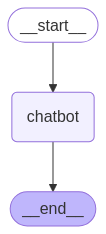

In [17]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [18]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

User: What do you know about LangGraph?


TypeError: 'method' object is not subscriptable